In [1]:
from huggingface_hub import login
login()

In [2]:
using_colab = True

In [3]:
if using_colab:
    import sys, os, pathlib, re
    import torch, torchvision

    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())

    !{sys.executable} -m pip install -q decord ultralytics

    repo_dir = "/content/sam3"
    if os.path.exists(repo_dir):
        !rm -rf {repo_dir}
    !git clone -q https://github.com/facebookresearch/sam3.git {repo_dir}

    pyproject = pathlib.Path(repo_dir) / "pyproject.toml"
    text = pyproject.read_text()
    text = re.sub(r'"numpy==[^"]+",?', "", text)
    pyproject.write_text(text)

    %cd {repo_dir}
    !{sys.executable} -m pip install -q -e .
    %cd /content

    if "sam3" in sys.modules:
        del sys.modules["sam3"]
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.7 MB/s eta 0:00:00
/content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.5 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavio

In [3]:
import shutil
from pathlib import Path

import yaml
import numpy as np
from PIL import Image
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

from ultralytics import YOLO
import random
random.seed(42)

In [4]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive/')
DRIVE_PATH = "/content/drive/MyDrive" #update the path with the location of zipfile

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [22]:
!ls /content/drive/MyDrive/duckietown_dataset

duckietown_dataset


In [24]:
# Unzip the dataset
DATASET_DIR_NAME = "duckietown_dataset"
DATASET_ZIP_NAME = f"{DATASET_DIR_NAME}.zip"
DATASET_DIR_PATH = "/content/drive/MyDrive/duckietown_dataset/duckietown_dataset"
TRAIN_DIR = "train"
VALIDATION_DIR = "val"
IMAGES_DIR = "images"
LABELS_DIR = "labels"


def show_info(base_path: str):
  for l1 in [TRAIN_DIR, VALIDATION_DIR]:
    for l2 in [IMAGES_DIR, LABELS_DIR]:
      p = os.path.join(base_path, l1, l2)
      print(f"#Files in {l1}/{l2}: {len(os.listdir(p))}")


def unzip_dataset():
  zip_path = os.path.join(DRIVE_PATH, DATASET_ZIP_NAME)
  assert os.path.exists(zip_path)

  print("Unpacking zipped data...")
  shutil.unpack_archive(zip_path, DATASET_DIR_PATH)

  print(f"Zipped dataset unpacked to {DATASET_DIR_PATH}")
  show_info(DATASET_DIR_PATH)




unzip_dataset()

Unpacking zipped data...
Zipped dataset unpacked to /content/drive/MyDrive/duckietown_dataset/duckietown_dataset
#Files in train/images: 840
#Files in train/labels: 0
#Files in val/images: 239
#Files in val/labels: 0


In [25]:
DATASET_DIR = Path(DATASET_DIR_PATH)
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
CLASSES_YAML = DATASET_DIR / "classes.yaml"

In [26]:
%%writefile /content/duckietown_dataset/data.yaml

train: /content/duckietown_dataset/train/images
val:   /content/duckietown_dataset/val/images

names:
  0: 'yellow rubber duck'

Overwriting /content/duckietown_dataset/data.yaml


In [27]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

In [14]:
!wget https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz -P /content/sam3/assets/

--2026-03-23 14:04:08--  https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz [following]
--2026-03-23 14:04:08--  https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1356917 (1.3M) [application/octet-stream]
Saving to: ‘/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz’

bpe_simple_vocab_16 100%[===================>]   1.29M  --.-KB/s    in 0.04s   

2026-03-23 14:04:09 (34.9 MB/s) - ‘/content/sam

In [28]:
def load_classes(classes_yaml):
  with open(classes_yaml, "r") as f:
    cfg = yaml.safe_load(f)
  items = sorted(cfg["names"].items(), key=lambda kv: int(kv[0]))
  return [name for _, name in items]


def xyxy_to_yolo_line(bbox, w, h, class_id):
  x1, y1, x2, y2 = bbox
  cx = (x1 + x2) / 2.0 / w
  cy = (y1 + y2) / 2.0 / h
  bw = (x2 - x1) / w
  bh = (y2 - y1) / h
  return f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


class Sam3AutoLabel:
  def __init__(
    self,
    train_dir,
    val_dir,
    dataset_dir,
    classes_yaml,
    bpe_path="/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz",
    confidence_threshold=0.3,
    device=None,
  ):
    self.train_dir = train_dir
    self.val_dir = val_dir
    self.dataset_dir = dataset_dir
    self.classes_yaml = classes_yaml

    if device is None:
      device = "cuda" if torch.cuda.is_available() else "cpu"
    self.device = device

    self.classes = load_classes(self.classes_yaml)

    self.model = build_sam3_image_model(bpe_path=str(bpe_path))
    self.model.to(device)
    self.model.eval()

    self.processor = Sam3Processor(
      self.model,
      confidence_threshold=confidence_threshold,
      device=device,
    )

  def _detect(self, img_path: Path):
    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    with torch.no_grad():
      if self.device == "cuda":
        ctx = torch.autocast("cuda", dtype=torch.bfloat16)
      else:
        from contextlib import nullcontext
        ctx = nullcontext()

      with ctx:
        st = self.processor.set_image(image)

        dets = []
        for class_id, prompt in enumerate(self.classes):
          out = self.processor.set_text_prompt(state=st, prompt=prompt)
          boxes = out.get("boxes")
          scores = out.get("scores")
          if boxes is None or scores is None:
            continue

          for b, s in zip(boxes, scores):
            s = float(s)
            if s < self.processor.confidence_threshold:
              continue
            dets.append(
              {
                  "bbox": b.tolist(),
                  "score": s,
                  "class_id": int(class_id),
              }
            )

    return dets, (w, h)

  def _label_split(self, split: str, max_images=None):
    import random  # kan ook bovenaan je script

    split_dir = self.train_dir if split == "train" else self.val_dir
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    img_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        img_paths.extend(img_dir.rglob(ext))

    # 🔥 random subset i.p.v. eerste N
    if max_images is not None:
        img_paths = random.sample(img_paths, min(max_images, len(img_paths)))

    for img_path in tqdm(img_paths, desc=f"Labeling {split}"):
        dets, (w, h) = self._detect(img_path)

        yolo_lines = []
        for d in dets:
            yolo_lines.append(
                xyxy_to_yolo_line(d["bbox"], w, h, d["class_id"])
            )

        label_path = lbl_dir / f"{img_path.stem}.txt"
        if yolo_lines:
            label_path.write_text("\n".join(yolo_lines))
        else:
            if label_path.exists():
                label_path.unlink()

  def run(self, max_images=None):
    self._label_split("train", max_images=max_images)
    self._label_split("val", max_images=max_images)

In [11]:
def visualize_labels_for_image(img_path: Path, labels_dir: Path, class_names=None, save_to: Path | None = None):
  img_path = Path(img_path)
  label_path = labels_dir / (img_path.stem + ".txt")

  if not label_path.exists():
    return

  image = Image.open(img_path).convert("RGB")
  w, h = image.size

  with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

  fig, ax = plt.subplots(figsize=(6, 6))
  ax.imshow(image)
  ax.axis("off")

  for line in lines:
    parts = line.split()
    if len(parts) != 5:
      continue
    class_id = int(parts[0])
    cx, cy, bw, bh = map(float, parts[1:])

    box_w = bw * w
    box_h = bh * h
    x1 = cx * w - box_w / 2
    y1 = cy * h - box_h / 2

    rect = plt.Rectangle(
      (x1, y1),
      box_w,
      box_h,
      fill=False,
      linewidth=2,
    )
    ax.add_patch(rect)

    label = str(class_id)
    if class_names is not None and 0 <= class_id < len(class_names):
      label = class_names[class_id]

    ax.text(
      x1,
      y1 - 2,
      label,
      fontsize=10,
      bbox=dict(facecolor="black", alpha=0.5),
      color="white",
    )

  if save_to is not None:
    save_to = Path(save_to)
    save_to.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_to, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
  else:
    plt.show()

In [30]:
CLASSES_YAML = "/content/duckietown_dataset/data.yaml"

# 🔥 Zorg dat labels folders bestaan (DIT TOEVOEGEN)
(TRAIN_DIR / "labels").mkdir(parents=True, exist_ok=True)
(VAL_DIR / "labels").mkdir(parents=True, exist_ok=True)

autolabel = Sam3AutoLabel(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    dataset_dir=DATASET_DIR,
    classes_yaml=CLASSES_YAML,
    confidence_threshold=0.3,
)

autolabel.run()

Labeling val: 100%|██████████| 239/239 [13:07<00:00,  3.29s/it]


📸 vbot1_2457.png


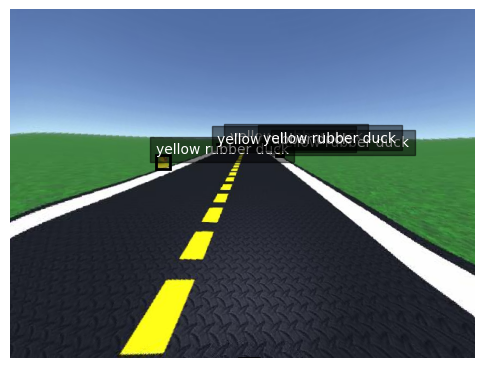

📸 vbot1_114.png


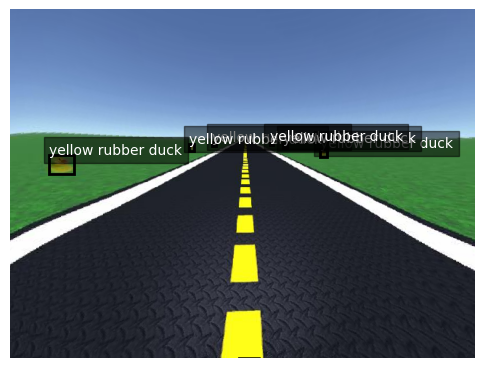

📸 vbot1_2817.png


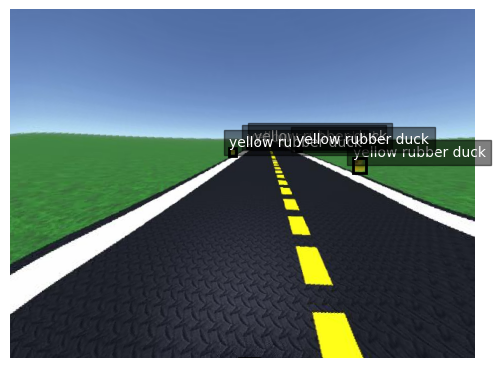

📸 vbot1_1914.png


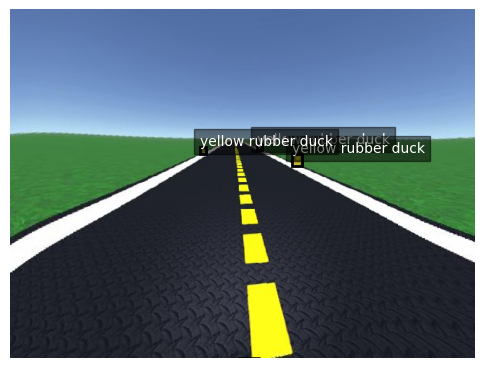

📸 vbot1_840.png


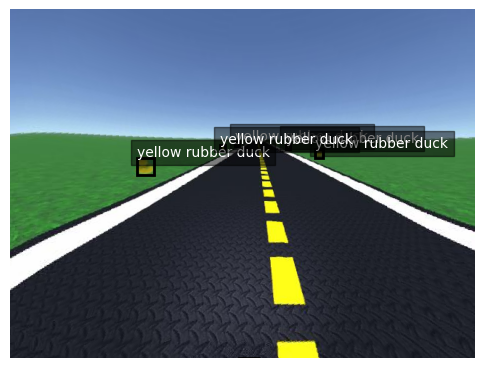

In [36]:
import random

train_images = TRAIN_DIR / "images"
train_labels = TRAIN_DIR / "labels"

labels = list(train_labels.glob("*.txt"))

sample_labels = random.sample(labels, min(5, len(labels)))

for label in sample_labels:
    # 🔥 probeer alle extensies
    img = None
    for ext in [".png", ".jpg", ".jpeg"]:
        candidate = train_images / f"{label.stem}{ext}"
        if candidate.exists():
            img = candidate
            break

    if img is None:
        print(f"⚠️ Image niet gevonden voor {label.name}")
        continue

    print(f"📸 {img.name}")

    visualize_labels_for_image(
        img_path=img,
        labels_dir=train_labels,
        class_names=load_classes(CLASSES_YAML),
    )

# Augmenten


In [1]:
!pip uninstall -y numpy
!pip install numpy==2.0.0
!pip install --upgrade albumentations

Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
  Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.0.0 which is incompatible.


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import cv2
import albumentations as A
from tqdm import tqdm
import shutil
from pathlib import Path

In [6]:
# 🔥 INPUT (gelabelde dataset)
DATASET_ROOT = Path("/content/drive/MyDrive/duckietown_dataset/duckietown_dataset")

INPUT_IMAGES = DATASET_ROOT / "train" / "images"
INPUT_LABELS = DATASET_ROOT / "train" / "labels"

# 🔥 OUTPUT (nieuwe dataset)
OUTPUT_ROOT = Path("/content/drive/MyDrive/dataset_final")
OUTPUT_IMAGES = OUTPUT_ROOT / "images"
OUTPUT_LABELS = OUTPUT_ROOT / "labels"

OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)

AUGMENTATIONS_PER_IMAGE = 5

transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.5, 0.9), p=0.6),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
    ),
)

def load_yolo_labels(label_path):
    boxes, labels = [], []
    if not label_path.exists():
        return boxes, labels

    with open(label_path, "r") as f:
        for line in f:
            cls, cx, cy, w, h = map(float, line.strip().split())
            boxes.append([cx, cy, w, h])
            labels.append(int(cls))
    return boxes, labels


def save_yolo_labels(path, boxes, labels):
    with open(path, "w") as f:
        for box, cls in zip(boxes, labels):
            cx, cy, w, h = box
            f.write(f"{cls} {cx} {cy} {w} {h}\n")


# 🔥 NIEUWE CORRECTE FIX (xyxy clamp)
def fix_boxes(boxes):
    fixed = []
    for cx, cy, w, h in boxes:
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2

        # clamp
        x1 = max(0.0, min(1.0, x1))
        y1 = max(0.0, min(1.0, y1))
        x2 = max(0.0, min(1.0, x2))
        y2 = max(0.0, min(1.0, y2))

        # skip kapotte boxes
        if x2 <= x1 or y2 <= y1:
            continue

        # terug naar YOLO
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        w = x2 - x1
        h = y2 - y1

        fixed.append([cx, cy, w, h])

    return fixed

print("✅ Setup klaar")

✅ Setup klaar


In [7]:
image_files = [
    f for f in os.listdir(INPUT_IMAGES)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print(f"Processing {len(image_files)} images...")

for filename in tqdm(image_files):
    img_path = INPUT_IMAGES / filename
    label_path = INPUT_LABELS / f"{Path(filename).stem}.txt"

    # 🔁 COPY originele data
    shutil.copy(img_path, OUTPUT_IMAGES / filename)

    if label_path.exists():
        shutil.copy(label_path, OUTPUT_LABELS / label_path.name)

    # 🔥 ALLEEN REAL IMAGES augmenten
    if filename.lower().endswith((".jpg", ".jpeg")):
        image = cv2.imread(str(img_path))
        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes, class_labels = load_yolo_labels(label_path)
        boxes = fix_boxes(boxes)

        if len(boxes) == 0:
            continue

        for i in range(AUGMENTATIONS_PER_IMAGE):
            augmented = transform(
                image=image,
                bboxes=boxes,
                class_labels=class_labels
            )

            aug_img = augmented["image"]
            aug_boxes = augmented["bboxes"]
            aug_labels = augmented["class_labels"]

            new_name = f"real_aug_{i}_{filename}"

            # save image
            cv2.imwrite(
                str(OUTPUT_IMAGES / new_name),
                cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
            )

            # save labels
            if len(aug_boxes) > 0:
                save_yolo_labels(
                    OUTPUT_LABELS / f"{Path(new_name).stem}.txt",
                    aug_boxes,
                    aug_labels
                )

print("✅ Dataset klaar zonder errors!")

Processing 840 images...


100%|██████████| 840/840 [00:27<00:00, 30.52it/s]

✅ Dataset klaar zonder errors!


In [17]:
from pathlib import Path

LABELS = Path("/content/drive/MyDrive/dataset_final/labels")

for file in LABELS.glob("*.txt"):
    with open(file, "r") as f:
        lines = f.readlines()

    fixed = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        cls = int(float(parts[0]))  # 🔥 fix
        rest = parts[1:]
        fixed.append(f"{cls} {' '.join(rest)}")

    with open(file, "w") as f:
        f.write("\n".join(fixed))

🧪 real_aug_1_duck16.jpeg


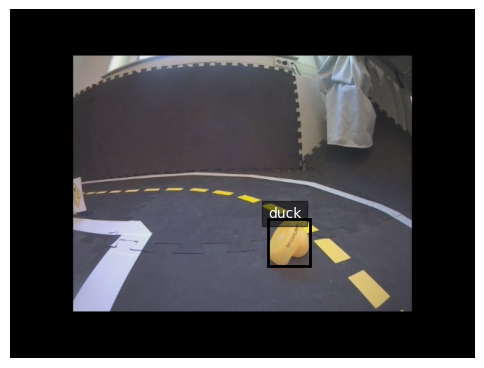

🧪 real_aug_0_duck4.jpeg


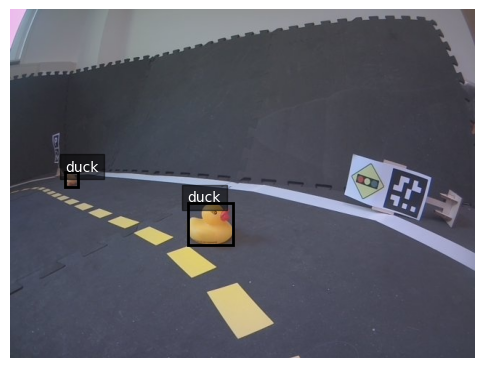

🧪 real_aug_0_duck25.jpeg


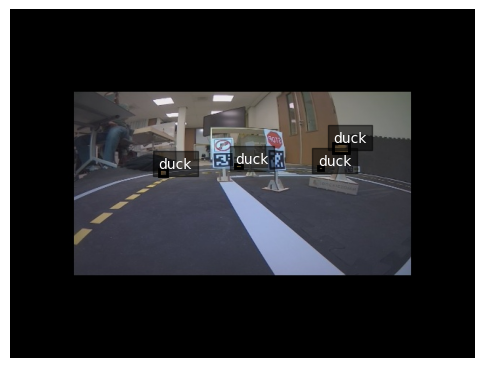

🧪 real_aug_0_duck22.jpeg


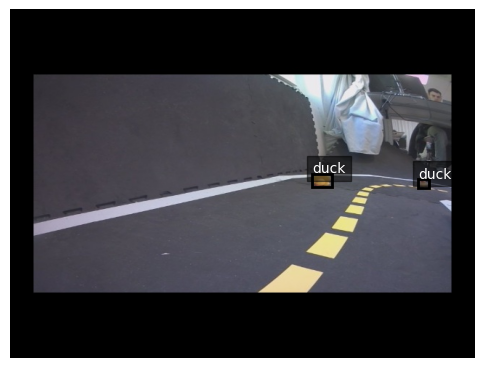

🧪 real_aug_1_duck30.jpeg


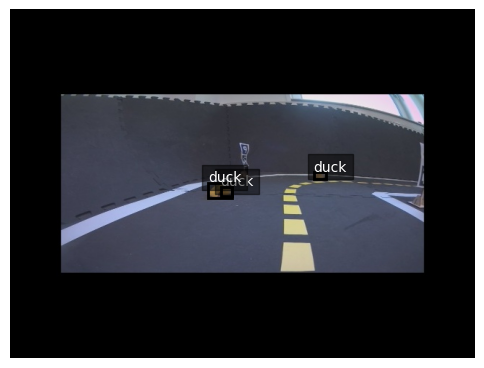

In [18]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

IMAGES = Path("/content/drive/MyDrive/dataset_final/images")
LABELS = Path("/content/drive/MyDrive/dataset_final/labels")

aug_images = list(IMAGES.glob("real_aug_*"))
samples = random.sample(aug_images, 5)

for img in samples:
    print(f"🧪 {img.name}")

    visualize_labels_for_image(
        img_path=img,
        labels_dir=LABELS,
        class_names=["duck"]
    )

# Modelleren

In [5]:
%%writefile /content/drive/MyDrive/dataset_final/data.yaml

train: /content/drive/MyDrive/dataset_final/images
val:   /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images

names:
  0: duck

Overwriting /content/drive/MyDrive/dataset_final/data.yaml


In [6]:
!ls /content/drive/MyDrive/dataset_final/images | head
!ls /content/drive/MyDrive/dataset_final/labels | head

!ls /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images | head
!ls /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/labels | head

duck10.jpeg
duck11.jpeg
duck12.jpeg
duck13.jpeg
duck14.jpeg
duck15.jpeg
duck16.jpeg
duck17.jpeg
duck18.jpeg
duck19.jpeg
duck11.txt
duck12.txt
duck13.txt
duck14.txt
duck15.txt
duck16.txt
duck17.txt
duck18.txt
duck19.txt
duck1.txt
duck41.jpeg
duck42.jpeg
duck43.jpeg
duck44.jpeg
duck45.jpeg
duck46.jpeg
duck47.jpeg
duck48.jpeg
duck49.jpeg
duck50.jpeg
duck41.txt
duck42.txt
duck43.txt
duck44.txt
duck46.txt
duck47.txt
duck48.txt
duck49.txt
duck50.txt
duck51.txt


In [7]:
!pip install ultralytics

In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # klein en snel (goed begin)

model.train(
    data="/content/drive/MyDrive/dataset_final/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="duck_detector",
)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset_final/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=duck_detector3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1ffc634680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [24]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/duck_detector2/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images",
    show=True,
    conf=0.25
)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck41.jpeg: 480x640 2 ducks, 179.2ms
image 2/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck42.jpeg: 480x640 3 ducks, 14.1ms
image 3/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck43.jpeg: 480x640 2 ducks, 60.1ms
image 4/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck44.jpeg: 480x640 1 duck, 67.5ms
image 5/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck45.jpeg: 480x640 (no detections), 37.9ms
image 6/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck46.jpeg: 480x640 1 duck, 41.0ms
image 7/239 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/duck47.jpeg: 480x640 2 ducks, 27.9ms
image 8/239 /content/drive/MyDrive/duckietown_dataset/duckietown_datase

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'duck'}
 obb: None
 orig_img: array([[[ 45,  44,  40],
         [ 45,  44,  40],
         [ 44,  43,  39],
         ...,
         [107, 111, 105],
         [ 91,  94,  85],
         [ 83,  87,  76]],
 
        [[ 45,  44,  40],
         [ 45,  44,  40],
         [ 45,  44,  40],
         ...,
         [110, 114, 108],
         [ 98, 101,  92],
         [ 88,  92,  81]],
 
        [[ 46,  45,  41],
         [ 45,  44,  40],
         [ 45,  44,  40],
         ...,
         [114, 120, 115],
         [105, 109, 103],
         [ 94,  99,  90]],
 
        ...,
 
        [[ 60,  56,  55],
         [ 61,  57,  56],
         [ 62,  58,  57],
         ...,
         [ 87,  69,  68],
         [ 90,  72,  71],
         [ 93,  75,  74]],
 
        [[ 60,  56,  55],
         [ 61,  57,  56],
         [ 62,  58,  57],
         ...,
         [ 87,  69, 

In [9]:
from ultralytics import YOLO
from pathlib import Path
import shutil

# 🔥 pad naar jouw getrainde model
best = Path("/content/runs/detect/duck_detector2/weights/best.pt")

if not best.exists():
    raise FileNotFoundError(f"Could not find best.pt at: {best}")

print(f"✅ Using checkpoint: {best}")

model = YOLO(str(best))

# 🔥 tijdelijke ONNX output (zelfde folder)
onnx_tmp = best.parent / "best.onnx"

print(f"🚀 Exporting ONNX to: {onnx_tmp}")

model.export(
    format="onnx",
    opset=18,
    imgsz=(480, 640),   # Duckiebot camera formaat
    simplify=True,
    dynamic=False,
    nms=True,
    half=False,         # 🔥 VEILIGER voor CPU (Duckiebot!)
    batch=1,
    device="cpu"        # 🔥 Duckiebot = CPU
)

# 🔥 definitieve locatie op Drive
model_path = Path("/content/drive/MyDrive/duck_model/best.onnx")
model_path.parent.mkdir(parents=True, exist_ok=True)

shutil.copy(onnx_tmp, model_path)

print(f"✅ ONNX model opgeslagen op: {model_path}")
print("🎉 Export finished successfully.")

✅ Using checkpoint: /content/runs/detect/duck_detector2/weights/best.pt
🚀 Exporting ONNX to: /content/runs/detect/duck_detector2/weights/best.onnx
Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/duck_detector2/weights/best.pt' with input shape (1, 3, 480, 640) BCHW and output shape(s) (1, 300, 6) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 345ms
Prepared 4 packages in 8.27s
Installed 4 packages in 266ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 

In [10]:
from ultralytics import YOLO
from pathlib import Path
import random

model = YOLO("/content/runs/detect/duck_detector2/weights/best.pt")

VAL_DIR = Path("/content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images")

img = random.choice(list(VAL_DIR.glob("*")))
print(f"📸 Testing: {img}")

results = model.predict(
    source=str(img),
    conf=0.25,
    save=True,   # 🔥 sla resultaat op
    save_txt=False
)

📸 Testing: /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/vbot1_846.png

image 1/1 /content/drive/MyDrive/duckietown_dataset/duckietown_dataset/val/images/vbot1_846.png: 480x640 3 ducks, 73.3ms
Speed: 2.2ms preprocess, 73.3ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

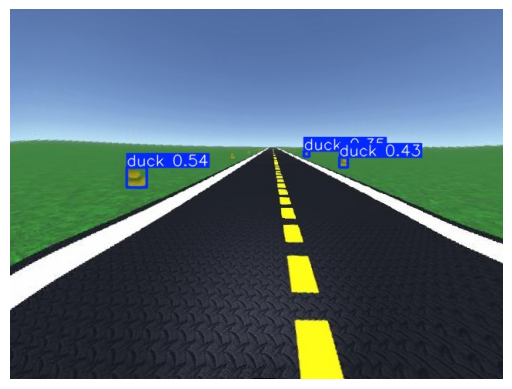

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

# YOLO slaat hier op:
save_dir = results[0].save_dir
saved_img = list(Path(save_dir).glob("*"))[0]

img = Image.open(saved_img)

plt.imshow(img)
plt.axis("off")